# Session 21

### Model Evaluation (Complete Guidance )-

## Model Evaluation Methods

In [135]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.datasets import load_digits
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    log_loss,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate,
    learning_curve,
    train_test_split,
    validation_curve,
)
from sklearn.multiclass import OneVsRestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.tree import DecisionTreeClassifier

from wcwidth import clip


In [2]:
digits = load_digits()
X = digits.data
y = digits.target
class_names = digits.target_names

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Classes:", class_names)

df = pd.DataFrame({
    "digit" : class_names,
    "count" : pd.Series(y).value_counts().sort_index(),
})
df

X shape: (1797, 64)
y shape: (1797,)
Classes: [0 1 2 3 4 5 6 7 8 9]


,digit,count
0,0,178
1,1,182
2,2,177
3,3,183
4,4,181
5,5,182
6,6,181
7,7,179
8,8,174
9,9,180


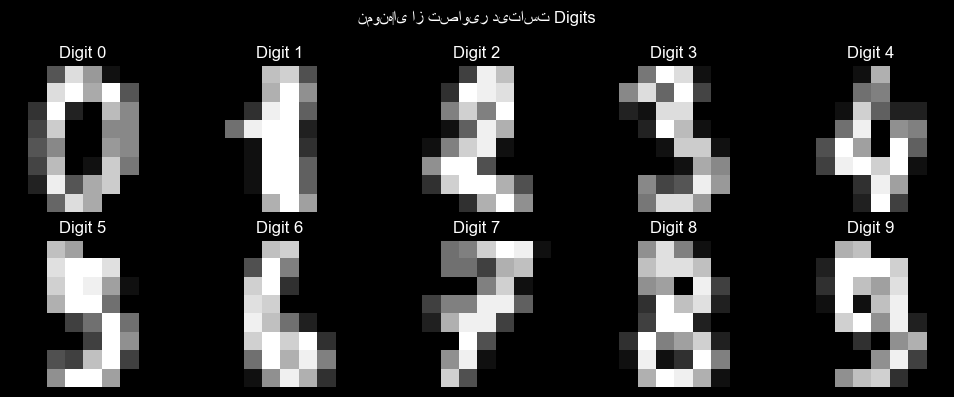

In [3]:
fig , axes = plt.subplots(2,5,figsize=(10,4))
#print(axes.ravel())
#print(fig)
for digit, ax in enumerate(axes.ravel()):
    idx = np.where(y == digit)[0][0]
    ax.imshow(digits.images[idx], cmap="gray")
    ax.set_title(f"Digit {digit}")
    ax.axis("off")
plt.suptitle("نمونه‌ای از تصاویر دیتاست Digits")
plt.tight_layout()
plt.show()




[0 1 2 3 4 5 6 7 8 9]
[178 182 177 183 181 182 181 179 174 180]


<Axes: >

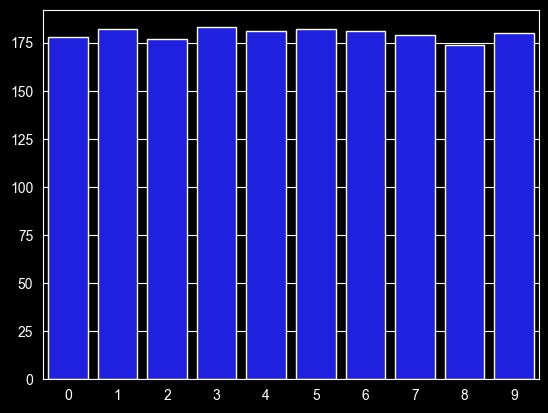

In [4]:
count = np.unique(y, return_counts=True)
print(count[0])
print(count[1])

sns.barplot(x = count[0], y = count[1], color = "blue")

### Types of Model

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y,
)

models = {
    'Logistic Regression' : Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=3000,random_state=42)),
    ]),

    'MLP Classifier' : Pipeline([
        ('scaler', StandardScaler()),
        ('model', MLPClassifier(hidden_layer_sizes=(64, 32),
                    activation="relu",
                    alpha=1e-4,
                    learning_rate_init=0.001,
                    max_iter=400,
                    random_state=42,)),
    ]),

    'Decision Tree' : DecisionTreeClassifier(max_depth=10, random_state=42),

    'Random Forest' : RandomForestClassifier(n_estimators=300,
        random_state=42,
        n_jobs=1,),

}

### Model Training

In [6]:
for name , model in models.items():
    model.fit(X_train, y_train)

### Basic model evaluation with f1,precision, recall, accuracy

In [7]:
summary_rows = []

for name , model in models.items():
    y_pred = model.predict(X_test)

    summary_rows.append(
        {
            "name" : name,
            'accuracy' : accuracy_score(y_test, y_pred),
            'precision_macro' : precision_score(y_test, y_pred,average='macro'),
            'recall_macro' : recall_score(y_test, y_pred,average='macro'),
            'f1_macro' : f1_score(y_test, y_pred,average='macro'),

        }
    )

metrics_df = pd.DataFrame(summary_rows).sort_values('f1_macro', ascending = False)
metrics_df

,name,accuracy,precision_macro,recall_macro,f1_macro
0,Logistic Regression,0.977778,0.977767,0.977661,0.977641
3,Random Forest,0.968889,0.969450,0.968365,0.968346
1,MLP Classifier,0.966667,0.967054,0.966598,0.966588
2,Decision Tree,0.835556,0.840397,0.834825,0.835585


              precision    recall  f1-score   support

           0       1.00      0.98      0.99        45
           1       0.93      0.93      0.93        46
           2       0.96      1.00      0.98        44
           3       0.98      0.98      0.98        46
           4       0.96      0.96      0.96        45
           5       0.98      0.98      0.98        46
           6       1.00      0.96      0.98        45
           7       0.94      1.00      0.97        45
           8       0.95      0.93      0.94        43
           9       0.98      0.96      0.97        45

    accuracy                           0.97       450
   macro avg       0.97      0.97      0.97       450
weighted avg       0.97      0.97      0.97       450



<Axes: >

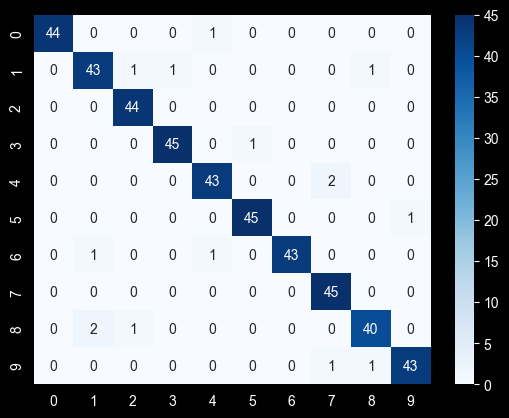

In [8]:
# Plot Confusion Matrix for mlp
mlp_model = models['MLP Classifier']

y_pred_mlp = mlp_model.predict(X_test)

print(classification_report(y_test, y_pred_mlp))

cm = confusion_matrix(y_test, y_pred_mlp)

sns.heatmap(cm, annot=True,cmap="Blues")

### Train vs. Test Accuracy Comparison-


Finding Generalization ( Overfitting vs underfitting vs good fit)

,model,train_accuracy,test_accuracy
0,Logistic Regression,1.000000,0.977778
1,MLP Classifier,1.000000,0.966667
2,Decision Tree,0.988864,0.835556
3,Random Forest,1.000000,0.968889


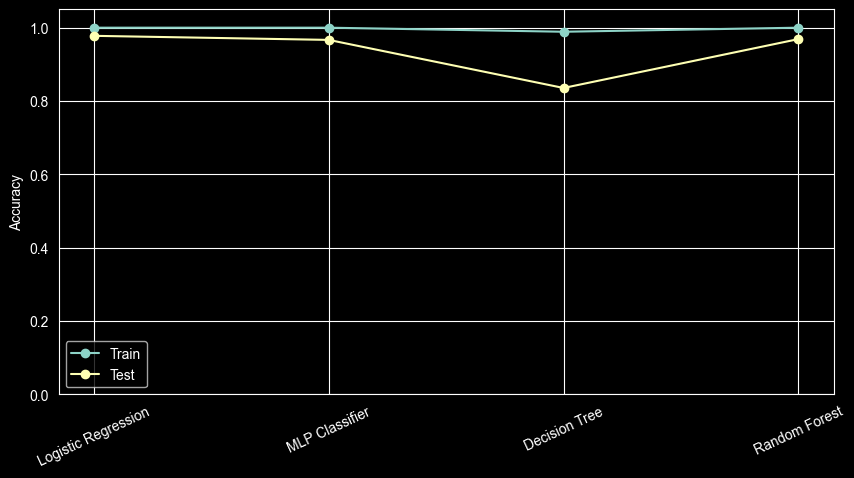

In [9]:
accuracy_rows = []
for name, model in models.items():
    accuracy_rows.append(
        {
            "model": name,
            "train_accuracy": accuracy_score(y_train, model.predict(X_train)),
            "test_accuracy": accuracy_score(y_test, model.predict(X_test)),
        }
    )

accuracy_df = pd.DataFrame(accuracy_rows)
display(accuracy_df)

plt.figure(figsize=(10,5))

plt.plot(
    accuracy_df["model"],
    accuracy_df["train_accuracy"],
    marker="o",
    label="Train"
)

plt.plot(
    accuracy_df["model"],
    accuracy_df["test_accuracy"],
    marker="o",
    label="Test"
)

plt.ylim(0,1.05)
plt.xticks(rotation=25)
plt.ylabel("Accuracy")
plt.legend()
plt.show()



As you see the Decision tree is overfitting

### Validation Curve - Bias-Variance Trade-off

The main purpose of a validation curve is:

Find the best value of a hyperparameter.

----

A validation curve shows how training and validation performance changes as a hyperparameter varies. It helps select the optimal hyperparameter value and diagnose underfitting or overfitting. For example, increasing decision tree depth may improve training accuracy but eventually decrease validation accuracy due to overfitting.

,max_depth,train_accuracy,test_accuracy
0,1,0.200445,0.191111
1,2,0.322940,0.306667
2,3,0.492947,0.475556
3,4,0.599109,0.575556
4,5,0.709725,0.664444


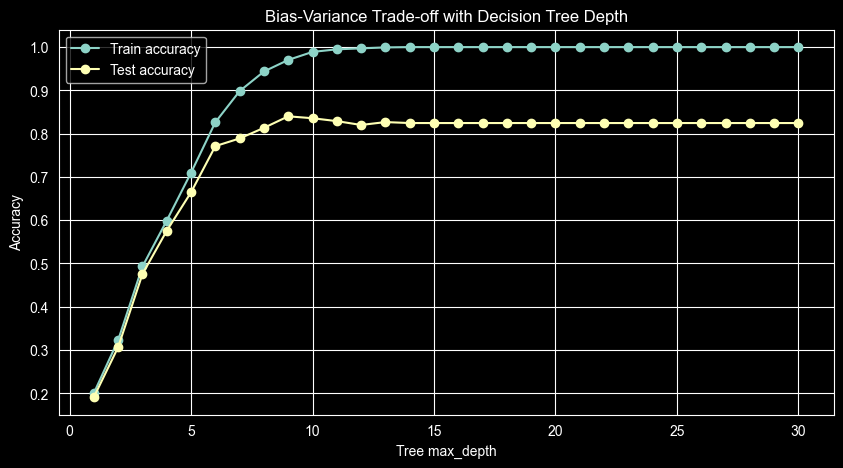

In [10]:
depths = range(1, 31)
bias_variance_rows = []

for depth in depths:
    tree = DecisionTreeClassifier(max_depth=depth, random_state=42)
    tree.fit(X_train, y_train)
    bias_variance_rows.append(
        {
            "max_depth": depth,
            "train_accuracy": accuracy_score(y_train, tree.predict(X_train)),
            "test_accuracy": accuracy_score(y_test, tree.predict(X_test)),
        }
    )

bv_df = pd.DataFrame(bias_variance_rows)
display(bv_df.head())

plt.figure(figsize=(10, 5))
plt.plot(bv_df["max_depth"], bv_df["train_accuracy"], marker="o", label="Train accuracy")
plt.plot(bv_df["max_depth"], bv_df["test_accuracy"], marker="o", label="Test accuracy")
plt.xlabel("Tree max_depth")
plt.ylabel("Accuracy")
plt.title("Bias-Variance Trade-off with Decision Tree Depth")
plt.legend()
plt.show()

#### Another way

In [11]:
train_scores, val_scores = validation_curve(
    DecisionTreeClassifier(random_state=42),
    X,
    y,
    param_name="max_depth",
    param_range=range(1,31),
    cv=5,
    scoring="accuracy"
)
print(train_scores.shape)


(30, 5)


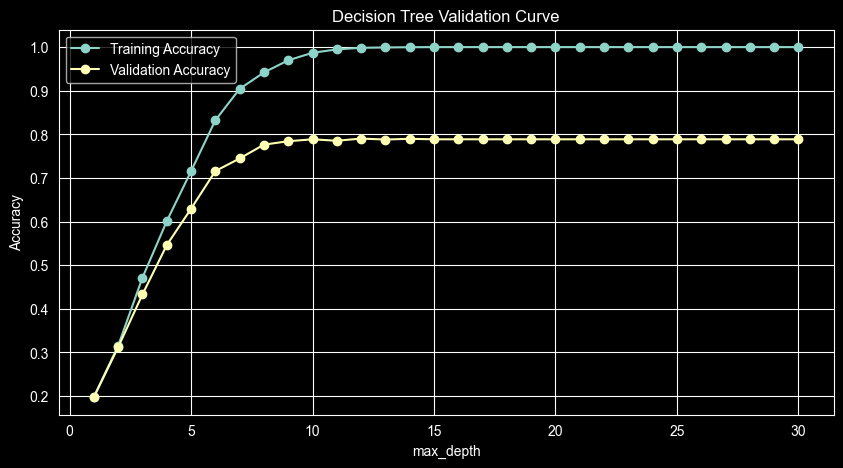

In [12]:
import numpy as np
import matplotlib.pyplot as plt

depth_range = range(1, 31)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)

val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)


plt.figure(figsize=(10,5))

plt.plot(
    depth_range,
    train_mean,
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    depth_range,
    val_mean,
    marker="o",
    label="Validation Accuracy"
)


plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Decision Tree Validation Curve")

plt.legend()
plt.grid(True)

plt.show()

### Learning Curve
A learning curve answers this question:

"Would giving the model more training data improve its performance?"

It helps us understand:

Is the model underfitting? (high bias)

Is the model overfitting? (high variance)

Would collecting more data help?

-------------

Learning curves show how model performance changes as the training set size increases. They are used to diagnose bias and variance problems and determine whether collecting more data is likely to improve the model.

we use two plot val and train

-----

NOTE : Accuracy curve helps us find best Epoch but here find best number of training examples

In [13]:
mlp_model = models['MLP Classifier']

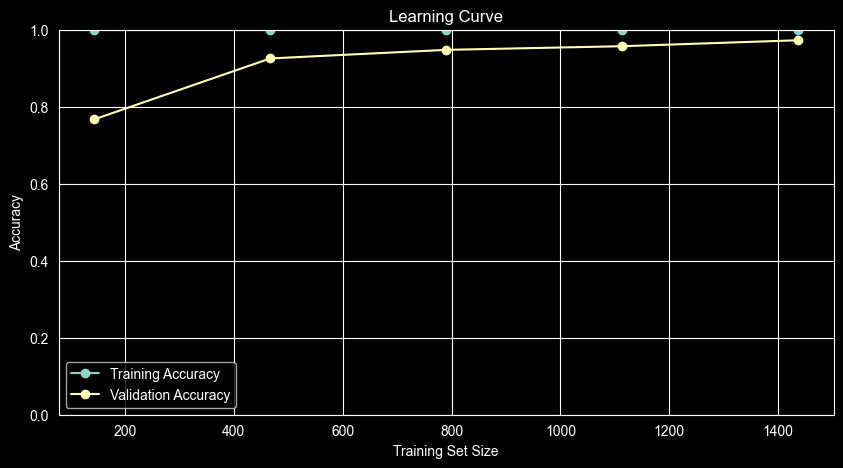

In [14]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42,
)

train_sizes, train_scores, validation_scores = learning_curve(
    mlp_model,
    X,
    y,
    cv=cv,
    scoring="accuracy",
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(validation_scores, axis=1)
val_std = np.std(validation_scores, axis=1)


plt.figure(figsize=(10,5))

plt.plot(
    train_sizes,
    train_mean,
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    train_sizes,
    val_mean,
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve")

plt.ylim(0, 1)

plt.legend()
plt.grid(True)

plt.show()

### ROC Curve and AUC

In [15]:
y_target = (y==8)
print(len(y_target))
y_target

1797


array([False, False, False, ...,  True, False,  True])

In [87]:
y_target = (y==8).astype(int)
y_target

array([0, 0, 0, ..., 1, 0, 1])

In [88]:
df = zip(X,y_target)

In [89]:
df = pd.DataFrame(df, columns=["X", "y_target"])
df

,X,y_target
0,"[0.0, 0.0, 5.0, 13.0, 9.0, 1.0, 0.0, 0.0, 0.0,...",0
1,"[0.0, 0.0, 0.0, 12.0, 13.0, 5.0, 0.0, 0.0, 0.0...",0
2,"[0.0, 0.0, 0.0, 4.0, 15.0, 12.0, 0.0, 0.0, 0.0...",0
3,"[0.0, 0.0, 7.0, 15.0, 13.0, 1.0, 0.0, 0.0, 0.0...",0
4,"[0.0, 0.0, 0.0, 1.0, 11.0, 0.0, 0.0, 0.0, 0.0,...",0
...,...,...
1792,"[0.0, 0.0, 4.0, 10.0, 13.0, 6.0, 0.0, 0.0, 0.0...",0
1793,"[0.0, 0.0, 6.0, 16.0, 13.0, 11.0, 1.0, 0.0, 0....",0
1794,"[0.0, 0.0, 1.0, 11.0, 15.0, 1.0, 0.0, 0.0, 0.0...",1
1795,"[0.0, 0.0, 2.0, 10.0, 7.0, 0.0, 0.0, 0.0, 0.0,...",0


In [90]:
from sklearn.metrics import classification_report, roc_curve, auc


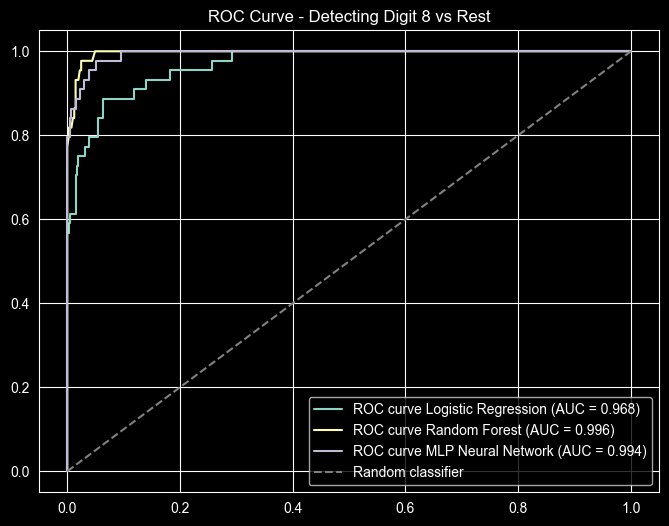

[{'model': 'Logistic Regression', 'roc_auc': 0.9681482310792655},
 {'model': 'Random Forest', 'roc_auc': 0.9963334079713391},
 {'model': 'MLP Neural Network', 'roc_auc': 0.9938423645320197}]

In [100]:
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X,
    y_target,
    test_size=0.25,
    random_state=42,
    stratify=y_target,
)
binary_models = {
    "Logistic Regression": Pipeline(
        [
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=3000, random_state=42)),
        ]
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=1,
    ),
    "MLP Neural Network": Pipeline(
        [
            ("scaler", StandardScaler()),
            (
                "model",
                MLPClassifier(
                    hidden_layer_sizes=(64, 32),
                    max_iter=400,
                    random_state=42,
                ),
            ),
        ]
    ),
}


plt.figure(figsize=(8, 6))
roc_rows = []

for name , model in binary_models.items():
    model.fit(X_train_b, y_train_b)
    scores = model.predict_proba(X_test_b)[:,1]
    fpr,tpr,thresholds = roc_curve(y_test_b, scores)
    roc_auc = auc(fpr,tpr)
    plt.plot(fpr, tpr, label=f'ROC curve {name} (AUC = %0.3f)' % roc_auc)
    roc_rows.append({
        "model": name,
                "roc_auc": roc_auc
,
    })

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random classifier")
plt.title("ROC Curve - Detecting Digit 8 vs Rest")
plt.legend()
plt.show()

roc_rows


In [34]:
y_bin = label_binarize(y,classes=np.unique(y))

X_train, X_test, y_train, y_test = train_test_split(
    X, y_bin, test_size=0.2, random_state=42)

In [36]:
y_bin

array([[1, 0, 0, ..., 0, 0, 0],
       [0, 1, 0, ..., 0, 0, 0],
       [0, 0, 1, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 1, 0],
       [0, 0, 0, ..., 0, 0, 1],
       [0, 0, 0, ..., 0, 1, 0]])

In [40]:
y_train

array([[0, 0, 0, ..., 0, 0, 0],
       [1, 0, 0, ..., 0, 0, 0],
       [1, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 1, ..., 0, 0, 0],
       [0, 0, 0, ..., 1, 0, 0],
       [0, 1, 0, ..., 0, 0, 0]])

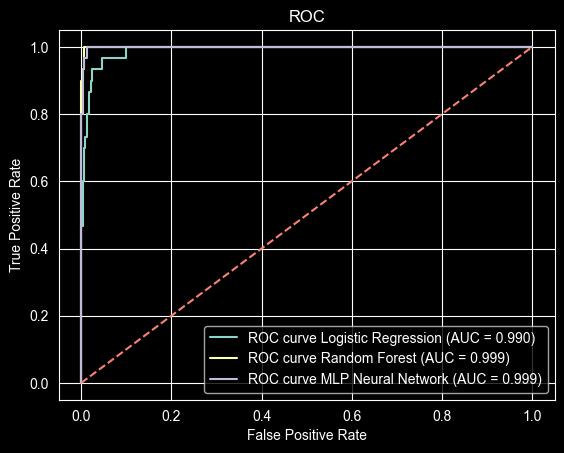

In [42]:
from sklearn.multiclass import OneVsRestClassifier
for name,model in binary_models.items():
    model = OneVsRestClassifier(model)
    model.fit(X_train, y_train)
    y_pred = model.predict_proba(X_test)[:,8]
    fpr, tpr , thresholds = roc_curve(
        y_test[:,8],
        y_pred,
    )
    roc_auc = auc(fpr,tpr)
    plt.plot(fpr,tpr,label=f'ROC curve {name} (AUC = %0.3f)' % roc_auc)

plt.title('ROC')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.plot([0, 1], [0, 1], '--')
plt.grid(True)
plt.legend()
plt.show()


In [44]:
models['Logistic Regression'].classes_

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

#### All Classes

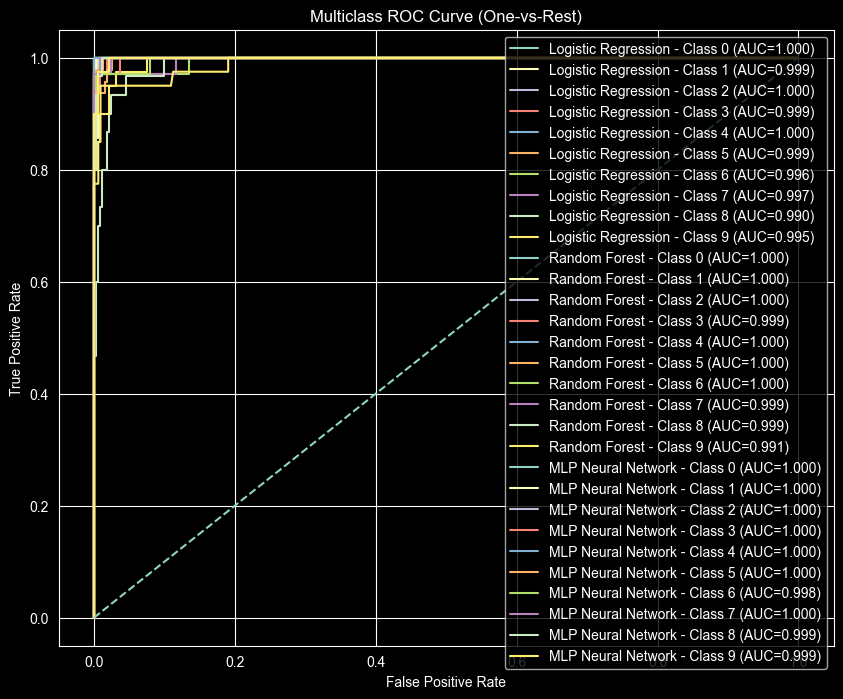

In [83]:
from sklearn.multiclass import OneVsRestClassifier

plt.figure(figsize=(10,8))

n_classes = y_test.shape[1]   # number of classes (10 digits)

for name, model in binary_models.items():

    model = OneVsRestClassifier(model)

    model.fit(X_train, y_train)

    y_pred = model.predict_proba(X_test)

    for i in range(n_classes):

        fpr, tpr, thresholds = roc_curve(
            y_test[:, i],
            y_pred[:, i]
        )

        roc_auc = auc(fpr, tpr)

        plt.plot(
            fpr,
            tpr,
            label=f"{name} - Class {i} (AUC={roc_auc:.3f})"
        )


plt.plot([0,1], [0,1], '--')

plt.title("Multiclass ROC Curve (One-vs-Rest)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.grid(True)
plt.legend()
plt.show()

## Precision-Recall Curve Trade-Off

The Precision-Recall curve is a tool used to evaluate a classification model by showing the trade-off between precision and recall at different decision thresholds.

It is especially useful when the positive class is rare or the dataset is imbalanced.



In [104]:
best_binary_name = max(roc_rows, key=lambda x:x["roc_auc"])["model"]
best_binary_model = binary_models[best_binary_name]
best_binary_model

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total 

In [106]:
y_pred = best_binary_model.predict_proba(X_test_b)[:,1]

In [112]:
precision, recall , threshilds = precision_recall_curve(
    y_test_b,
    y_pred,
)

ap = average_precision_score(y_test_b, y_pred)
print(f"Average Precision: {ap:.3f}")

Average Precision: 0.970


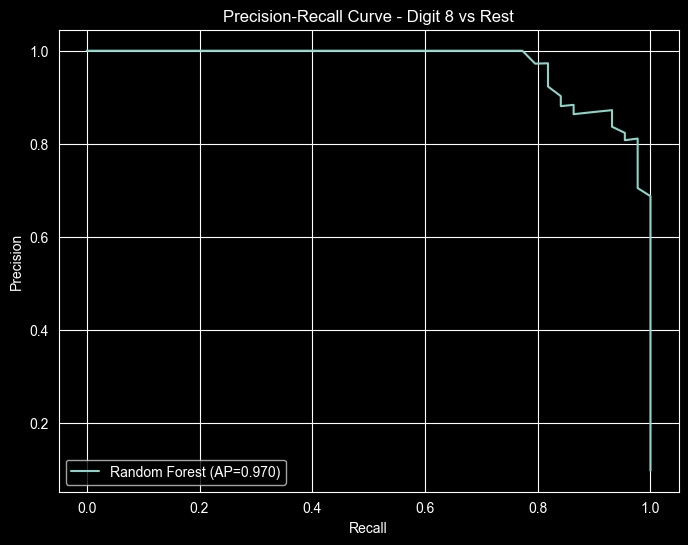

In [113]:
plt.figure(figsize=(8,6))

plt.plot(
    recall,
    precision,
    label=f"{best_binary_name} (AP={ap:.3f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Digit 8 vs Rest")

plt.legend()
plt.grid(True)

plt.show()

In [128]:
df = zip(thresholds,precision,recall)

In [129]:
df = pd.DataFrame(df,columns=["thresholds","precision","recall"])
df


,thresholds,precision,recall
0,0.000000,0.097778,1.000000
1,0.003333,0.132530,1.000000
2,0.006667,0.145594,0.863636
3,0.010000,0.163717,0.840909
4,0.013333,0.181818,0.772727
...,...,...,...
61,0.966667,0.000000,0.000000
62,0.970000,0.000000,0.000000
63,0.973333,0.000000,0.000000
64,0.976667,0.000000,0.000000


In [131]:
df["f1"] = (
    2 * df["precision"] * df["recall"]
    /
    (df["precision"] + df["recall"])
)
df

,thresholds,precision,recall,f1
0,0.000000,0.097778,1.000000,0.178138
1,0.003333,0.132530,1.000000,0.234043
2,0.006667,0.145594,0.863636,0.249180
3,0.010000,0.163717,0.840909,0.274074
4,0.013333,0.181818,0.772727,0.294372
...,...,...,...,...
61,0.966667,0.000000,0.000000,NaN
62,0.970000,0.000000,0.000000,NaN
63,0.973333,0.000000,0.000000,NaN
64,0.976667,0.000000,0.000000,NaN


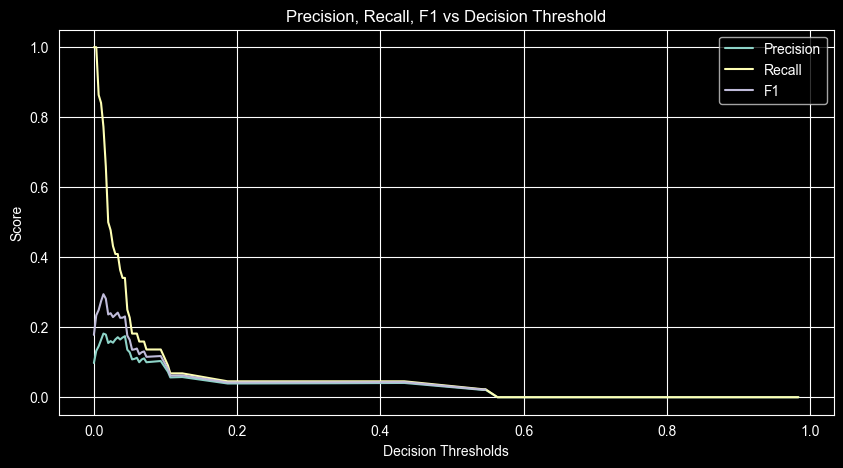

In [133]:
plt.figure(figsize=(10, 5))

plt.plot(
    df["thresholds"],
    df["precision"],
    label="Precision"
)

plt.plot(
    df["thresholds"],
    df["recall"],
    label="Recall"
)

plt.plot(
    df["thresholds"],
    df["f1"],
    label="F1"
)

plt.xlabel("Decision Thresholds")
plt.ylabel("Score")
plt.title("Precision, Recall, F1 vs Decision Threshold")

plt.legend()
plt.grid(True)

plt.show()

### Loss Curve

In [60]:
mlp_loss_model = Pipeline(
    [
        ("scaler", StandardScaler()),
        (
            "model",
            MLPClassifier(
                hidden_layer_sizes=(64, 32),
                activation="relu",
                solver="adam",
                alpha=1e-4,
                learning_rate_init=0.001,
                max_iter=400,
                random_state=42,
            ),
        ),
    ]
)

mlp_loss_model.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int32](10,)","[0,1,2,...,7,8,9]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,64
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value


In [61]:
loss_curve_values = mlp_loss_model.named_steps['model'].loss_curve_

In [62]:
len(loss_curve_values)
loss_curve_values

[7.138639966704542,
 6.164751004231781,
 5.370620323290866,
 4.647686383407702,
 3.962344637562718,
 3.3290686712008077,
 2.7919864732158235,
 2.3737115266769684,
 2.050962884836324,
 1.791192634162547,
 1.580526985280482,
 1.4045797325962248,
 1.261560718584078,
 1.1403405285303194,
 1.0358217743474478,
 0.9460915953926091,
 0.8663020699467918,
 0.7967712040128246,
 0.7342529445967452,
 0.678742483915594,
 0.6283639664379737,
 0.583133625667379,
 0.5432670330824072,
 0.5069971260815689,
 0.47386984084641415,
 0.44406681417932536,
 0.4156181720422518,
 0.39100608498201217,
 0.36794663943263667,
 0.34773993992077395,
 0.32860667601134536,
 0.3103914536013553,
 0.2948635452360334,
 0.280406106054219,
 0.26659865987714254,
 0.254570579895439,
 0.2421810119783604,
 0.23073867040742538,
 0.22059776524021588,
 0.2109320520829886,
 0.20151422927659648,
 0.1931651656226366,
 0.1850580713117317,
 0.17762012636264274,
 0.17019702546225987,
 0.16394640851267372,
 0.15776601849171923,
 0.151515044

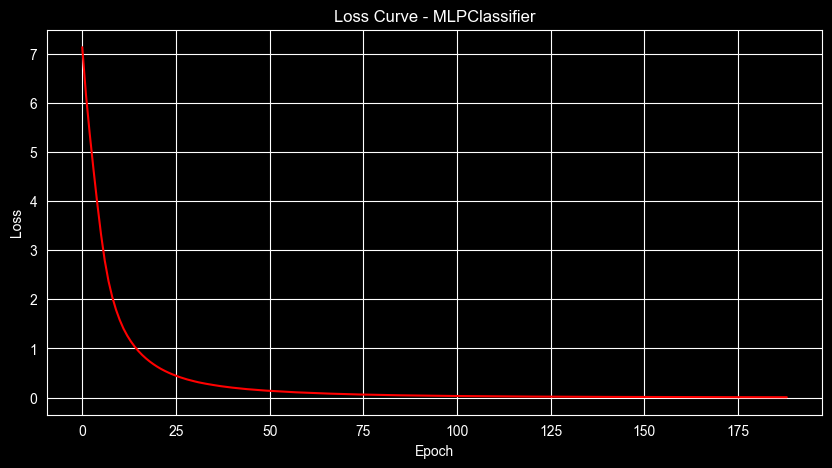

0.005943357453947471
0.9666666666666667


In [65]:
plt.figure(figsize=(10, 5))
plt.plot(loss_curve_values, "r")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve - MLPClassifier")
plt.show()

print(loss_curve_values[-1])
print(accuracy_score(y_test, mlp_loss_model.predict(X_test)))


### Accuaray and Loss During Epoch

In [66]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [68]:
epoch_model = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    alpha=1e-4,
    learning_rate_init=0.001,
    max_iter=1,
    warm_start=True,
    random_state=42,
)


C:\Users\top\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\top\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:304: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
C:\Users\top\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:304: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
C:\Users\top\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\top\AppData\Local\Programs\Python\Python311\Lib\site-

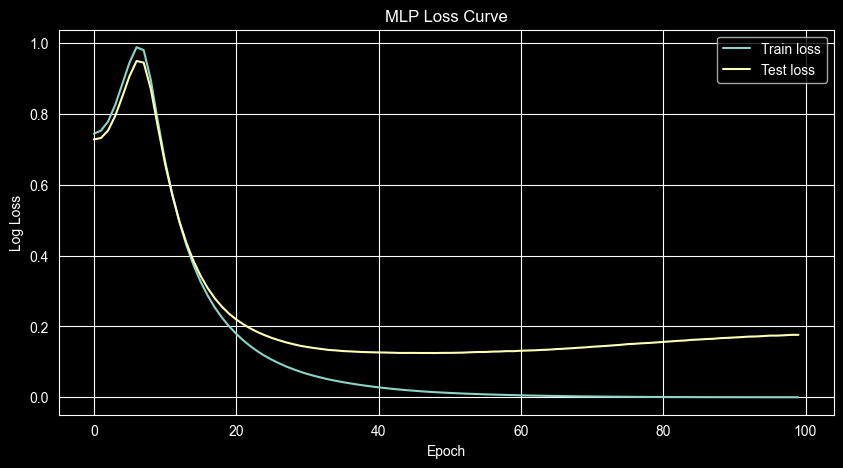

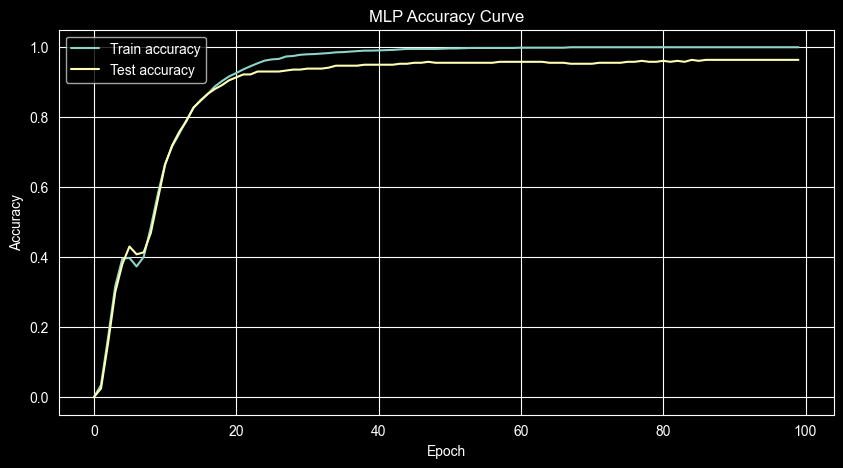

In [74]:
from sklearn.metrics import accuracy_score, log_loss
import matplotlib.pyplot as plt

epoch_model = Pipeline(
    [
        ("scaler", StandardScaler()),
        (
            "model",
            MLPClassifier(
                hidden_layer_sizes=(64, 32),
                activation="relu",
                solver="adam",
                alpha=1e-4,
                learning_rate_init=0.001,
                max_iter=1,
                warm_start=True,
                random_state=42,
            ),
        ),
    ]
)


train_acc = []
test_acc = []

train_loss = []
test_loss = []


for epoch in range(100):

    # one epoch of training
    epoch_model.fit(X_train, y_train)

    # predictions
    train_pred = epoch_model.predict(X_train)
    test_pred = epoch_model.predict(X_test)

    # probabilities for loss
    train_prob = epoch_model.predict_proba(X_train)
    test_prob = epoch_model.predict_proba(X_test)

    # accuracy
    train_acc.append(
        accuracy_score(y_train, train_pred)
    )

    test_acc.append(
        accuracy_score(y_test, test_pred)
    )

    # log loss
    train_loss.append(
        log_loss(y_train, train_prob)
    )

    test_loss.append(
        log_loss(y_test, test_prob)
    )


# Plot loss
plt.figure(figsize=(10,5))

plt.plot(train_loss, label="Train loss")
plt.plot(test_loss, label="Test loss")

plt.xlabel("Epoch")
plt.ylabel("Log Loss")
plt.title("MLP Loss Curve")

plt.legend()
plt.grid(True)
plt.show()


# Plot accuracy
plt.figure(figsize=(10,5))

plt.plot(train_acc, label="Train accuracy")
plt.plot(test_acc, label="Test accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("MLP Accuracy Curve")

plt.legend()
plt.grid(True)
plt.show()

### Cross Validation

In [77]:
cv_model = Pipeline(
    [
        ("scaler", StandardScaler()),
        (
            "model",
            MLPClassifier(
                hidden_layer_sizes=(64, 32),
                max_iter=350,
                random_state=42,
            ),
        ),
    ]
)

In [78]:
scoring = {
    "accuracy": "accuracy",
    "precision_macro": "precision_macro",
    "recall_macro": "recall_macro",
    "f1_macro": "f1_macro",
}


In [81]:
cv_results = cross_validate(
    cv_model,
    X,
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=1,
    return_train_score=True,
)

cv_summary = []
for metric in scoring:
    cv_summary.append(
        {
            "metric": metric,
            "train_mean": cv_results[f"train_{metric}"].mean(),
            "train_std": cv_results[f"train_{metric}"].std(),
            "validation_mean": cv_results[f"test_{metric}"].mean(),
            "validation_std": cv_results[f"test_{metric}"].std(),
        }
    )

display(pd.DataFrame(cv_summary))

,metric,train_mean,train_std,validation_mean,validation_std
0,accuracy,1.0,0.0,0.973844,0.007996
1,precision_macro,1.0,0.0,0.974666,0.007708
2,recall_macro,1.0,0.0,0.973768,0.007968
3,f1_macro,1.0,0.0,0.973818,0.007968


### Accuracy Curve (Training Accuracy Curve) - OUT OF this EXAMPLE - so built another data

Is exaclty like loss function curve but instead of loss in y-axis you use accuracy in y-axis


------



-------------


What is an Accuracy Curve?

An accuracy curve shows how the model's accuracy changes during the training process.

The x-axis is usually:

Epoch / Iteration

The y-axis is:

Accuracy

Usually we plot two curves:

Training Accuracy

Performance on data the model learns from.

Validation Accuracy

Performance on unseen validation data during training.

Example question it answers:

"Is my model learning correctly, and when does it start overfitting?"



--------

Q2: Why do we plot training and validation accuracy together?

Answer:

"Comparing them allows us to measure generalization. If training accuracy increases while validation accuracy decreases, the model is overfitting."

Q3: How do you know the best epoch?

Answer:

"The best epoch is usually where validation performance is highest. We can use early stopping to save the model at that point."

In [ ]:
[ Total Dataset ]
       │
       ├──► Training Set (60-80%): Used to train the model's weights.
       │
       ├──► Validation Set (10-20%): Used to tune hyperparameters and check for
       │                             overfitting *during* training.
       │
       └──► Test Set (10-20%): Kept in a vault. Only opened *once* at the very
                               end to see how the final model actually performs.

we can plot both loss and accuracy for training curves to see generalization and finding best epoch .

In [70]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import log_loss, accuracy_score

X, y = make_classification(
    n_samples=1500,
    n_features=20,
    n_informative=12,
    n_classes=2,
    random_state=42
)


X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


model = SGDClassifier(loss="log_loss", learning_rate="constant", eta0=0.005, random_state=42)
classes = np.unique(y)

train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []
epochs = 100

for epoch in range(epochs):

    model.partial_fit(X_train, y_train, classes=classes)


    train_preds = model.predict(X_train)
    train_probs = model.predict_proba(X_train)


    val_preds = model.predict(X_val)
    val_probs = model.predict_proba(X_val)

    train_losses.append(log_loss(y_train, train_probs))
    val_losses.append(log_loss(y_val, val_probs))


    train_accuracies.append(accuracy_score(y_train, train_preds))
    val_accuracies.append(accuracy_score(y_val, val_preds))



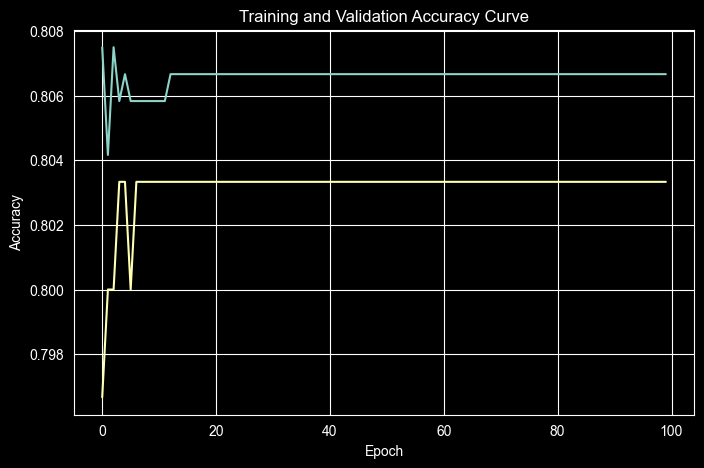

In [66]:
plt.figure(figsize=(8,5))

plt.plot(
    range(epochs),
    train_accuracies,
    label="Training Accuracy"
)

plt.plot(
    range(epochs),
    val_accuracies,
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy Curve")



plt.show()

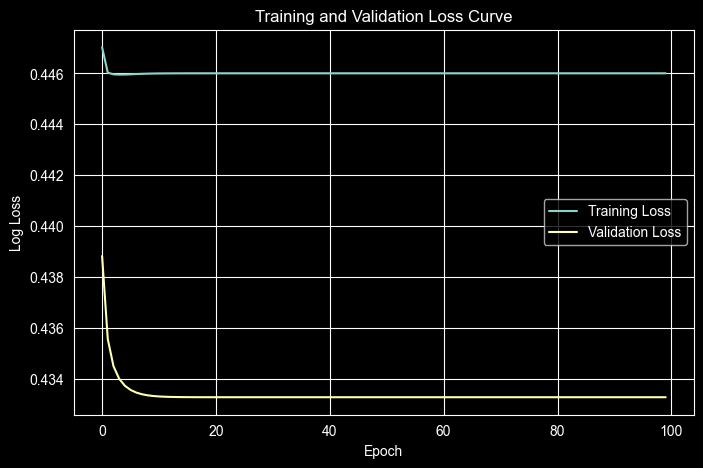

In [67]:
plt.figure(figsize=(8,5))

plt.plot(
    range(epochs),
    train_losses,
    label="Training Loss"
)

plt.plot(
    range(epochs),
    val_losses,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Log Loss")
plt.title("Training and Validation Loss Curve")

plt.legend()
plt.grid(True)

plt.show()